# 🚚 Delivery Route Optimization — ADA Capstone Project
## E-Commerce Logistics Using a Multi-Algorithm Approach
### Mritunjay Tripathi ; Roll Number : 2401420017

**Course:** Analysis and Design of Algorithms (ADA)

**Real-world context:** An e-commerce platform (like Amazon/Flipkart) must deliver parcels
to 7 locations using one vehicle. We apply the full ADA toolkit to solve each sub-problem
optimally.

| Task | Description | Paradigm |
|------|-------------|---------|
| 1 | Environment Setup | — |
| 2 | Input Modeling | — |
| 3 | Recurrence Route Cost | Divide & Conquer + Memoisation |
| 4 | Parcel Selection | Greedy + Dynamic Programming |
| 5 | Route Building | Dijkstra + MST (Prim's) |
| 6 | Optimal Sequence | TSP via Held-Karp DP |
| 7 | Profiling & Visualisation | Analysis |
| 8 | Summary & Reflection | Discussion |

## Task 1: Environment Setup

Install all required libraries with:
```bash
pip install matplotlib networkx jupyterlab memory_profiler
```

In [10]:
# Task 1 — Imports & environment check
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import itertools
import time
import sys
import math
import warnings
from scipy.spatial import distance_matrix
import os
warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#F9F9F9'
print("=" * 52)
print("  ENVIRONMENT VERIFICATION")
print("=" * 52)
print(f"  Python     : {sys.version.split()[0]}")
print(f"  NetworkX   : {nx.__version__}")
print(f"  Matplotlib : {plt.matplotlib.__version__}")
print("=" * 52)
print("  All libraries imported successfully!")

  ENVIRONMENT VERIFICATION
  Python     : 3.14.3
  NetworkX   : 3.6.1
  Matplotlib : 3.10.8
  All libraries imported successfully!


## Task 2: Input Modelling

### Graph Structure
- **Node 0**: Warehouse (origin and return destination)
- **Nodes 1–7**: Customer delivery locations (A–G)
- **Edge weights**: Euclidean distances between all coordinate pairs

### Parcel Metadata
Each parcel carries: `value (Rs)`, `weight (kg)`, `time_window = [open_hour, close_hour]`

### Vehicle Constraints
| Property | Value |
|----------|-------|
| Max payload | 25 kg |
| Speed | 10 distance-units / hour |
| Departure time | 08:00 |

In [11]:
# Task 2 — Clean Data Definitions
# Locations
location_names = ['Warehouse', 'Loc_A', 'Loc_B', 'Loc_C',
                  'Loc_D', 'Loc_E', 'Loc_F', 'Loc_G']
coords = {
    0: (0, 0), 1: (2, 5), 2: (5, 4), 3: (6, 1),
    4: (4, -3), 5: (1, -4), 6: (-3, -2), 7: (-4, 3)
}
N = len(location_names)
# Distance Matrix
def euclidean(p1, p2):
    return round(math.dist(p1, p2), 2)
dist_matrix = [[euclidean(coords[i], coords[j]) for j in range(N)] for i in range(N)]
# Parcels
parcels = [
    {'id': i+1, 'location': i+1, 'name': location_names[i+1],
     'value': v, 'weight': w, 'tw': tw}
    for i, (v, w, tw) in enumerate([
        (100, 5, (8, 12)),
        (150, 8, (9, 13)),
        (200,10, (10,14)),
        ( 80, 3, (8, 11)),
        (120, 6, (11,15)),
        (180, 9, (12,16)),
        ( 90, 4, (9, 14))
    ])
]
# Vehicle
vehicle = {'max_weight': 25, 'speed': 10, 'start_time': 8.0}
# Display
print("PARCEL INVENTORY")
print(f"{'ID':<5}{'Name':<10}{'Value(Rs)':<12}{'Weight(kg)':<13}{'V/W Ratio':<11}{'Time Window'}")
print("-" * 64)
for p in parcels:
    ratio = p['value'] / p['weight']
    print(f"{p['id']:<5}{p['name']:<10}{p['value']:<12}{p['weight']:<13}{ratio:<11.2f}{p['tw']}")
print("-" * 64)
print(f"{'TOTAL':<5}{'':<10}{sum(p['value'] for p in parcels):<12}{sum(p['weight'] for p in parcels):<13}")
print()
print(f"Vehicle: max_weight={vehicle['max_weight']} kg | speed={vehicle['speed']} u/hr | departs at {vehicle['start_time']}h")

PARCEL INVENTORY
ID   Name      Value(Rs)   Weight(kg)   V/W Ratio  Time Window
----------------------------------------------------------------
1    Loc_A     100         5            20.00      (8, 12)
2    Loc_B     150         8            18.75      (9, 13)
3    Loc_C     200         10           20.00      (10, 14)
4    Loc_D     80          3            26.67      (8, 11)
5    Loc_E     120         6            20.00      (11, 15)
6    Loc_F     180         9            20.00      (12, 16)
7    Loc_G     90          4            22.50      (9, 14)
----------------------------------------------------------------
TOTAL          920         45           

Vehicle: max_weight=25 kg | speed=10 u/hr | departs at 8.0h


## Task 3: Recurrence-based Route Cost Estimation

### Recurrence Relation

```
route_cost(visited, current) =
    dist[current][0]                                                    (base: all visited → return)
    min { dist[current][u] + route_cost(visited ∪ {u}, u) }           (recursive: try each unvisited u)
```

**Memoisation key:** `(frozenset(visited), current_node)`  
**Without memo:** O(n!)  — **With memo:** O(n² · 2ⁿ)  (same asymptotic bound as Held-Karp)

In [12]:
sys.setrecursionlimit(50000)
memo = {}
def route_cost(visited, current, nodes, dist):
# Returns minimum cost to visit all nodes and return to warehouse (0)
    # Base case: all visited → return to warehouse
    if len(visited) == len(nodes):
        return dist[current][0]
    key = (visited, current)
    if key in memo:
        return memo[key]
    min_cost = float('inf')
    # Try all unvisited nodes
    for nxt in nodes:
        if nxt not in visited:
            cost = dist[current][nxt] + route_cost(
                visited | {nxt}, nxt, nodes, dist
            )
            min_cost = min(min_cost, cost)
    memo[key] = min_cost
    return min_cost
print("RECURRENCE ROUTE COST — RESULTS BY SUBSET SIZE")
print(f"{'Nodes':<34}{'Min Cost':>10}  {'Memo Entries':>14}  {'Time (ms)':>10}")
print("-" * 74)
recur_profile = {}
for size in range(2, 8):
    nodes = tuple(range(1, size + 1))
    memo.clear()
    start = time.perf_counter()
    cost = route_cost(frozenset(), 0, nodes, dist_matrix)
    elapsed = (time.perf_counter() - start) * 1000
    recur_profile[size] = elapsed
    print(f"{str(list(nodes)):<34}{cost:>10.2f}  {len(memo):>14}  {elapsed:>10.4f}")

RECURRENCE ROUTE COST — RESULTS BY SUBSET SIZE
Nodes                               Min Cost    Memo Entries   Time (ms)
--------------------------------------------------------------------------
[1, 2]                                 14.95               3      0.0098
[1, 2, 3]                              17.79              10      0.0069
[1, 2, 3, 4]                           21.18              29      0.0226
[1, 2, 3, 4, 5]                        23.46              76      0.0705
[1, 2, 3, 4, 5, 6]                     27.42             187      0.2315
[1, 2, 3, 4, 5, 6, 7]                  33.10             442      0.7166


## Task 4: Greedy + DP for Delivery Planning

### 4a. Greedy Selection
Rank parcels by **value ÷ weight** (descending). Accept each parcel that still fits.  
**Complexity:** O(n log n) — fast, but not guaranteed optimal for 0/1 selection.

In [13]:
# Task 4a — Greedy parcel selection
def greedy_selection(parcels, max_weight):
    """Sort by V/W ratio, pick greedily. O(n log n)"""
    sorted_p = sorted(parcels, key=lambda p: p['value'] / p['weight'], reverse=True)
    selected, total_w = [], 0
    for p in sorted_p:
        if total_w + p['weight'] <= max_weight:
            selected.append(p)
            total_w += p['weight']
    return selected
t0           = time.perf_counter()
greedy_result = greedy_selection(parcels, vehicle['max_weight'])
greedy_time  = (time.perf_counter() - t0) * 1000
g_val = sum(p['value']  for p in greedy_result)
g_wt  = sum(p['weight'] for p in greedy_result)
print("GREEDY SELECTION RESULT")
print(f"{'ID':<5}{'Name':<10}{'Value':<9}{'Weight':<10}{'V/W Ratio'}")
print("-" * 47)
for p in greedy_result:
    print(f"{p['id']:<5}{p['name']:<10}{p['value']:<9}{p['weight']:<10}{p['value']/p['weight']:.2f}")
print("-" * 47)
print(f"Total Value  : {g_val} Rs")
print(f"Total Weight : {g_wt} / {vehicle['max_weight']} kg")
print(f"Parcels      : {len(greedy_result)} / {len(parcels)}")
print(f"Time         : {greedy_time:.5f} ms")

GREEDY SELECTION RESULT
ID   Name      Value    Weight    V/W Ratio
-----------------------------------------------
4    Loc_D     80       3         26.67
7    Loc_G     90       4         22.50
1    Loc_A     100      5         20.00
3    Loc_C     200      10        20.00
-----------------------------------------------
Total Value  : 470 Rs
Total Weight : 22 / 25 kg
Parcels      : 4 / 7
Time         : 0.04650 ms


### 4b. DP 0/1 Knapsack

**State:** `dp[i][w]` = maximum value using the first `i` parcels with weight budget `w`

**Recurrence:**
```
dp[i][w] = dp[i-1][w]                                       (skip parcel i)
           max(dp[i][w],  dp[i-1][w - wt[i]] + val[i])      (take parcel i, if w >= wt[i])
```
**Backtracking** recovers the exact items selected.  
**Complexity:** O(n · W) time, O(n · W) space

In [14]:
# Task 4b — DP 0/1 Knapsack
def dp_knapsack(parcels, max_weight):
    n, W = len(parcels), max_weight
    dp = [[0] * (W + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        wt, val = parcels[i-1]['weight'], parcels[i-1]['value']
        for w in range(W + 1):
            dp[i][w] = dp[i-1][w]  # skip
            if w >= wt:
                dp[i][w] = max(dp[i][w], dp[i-1][w - wt] + val)
    # Backtracking
    selected, w = [], W
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i-1][w]:
            selected.append(parcels[i-1])
            w -= parcels[i-1]['weight']
    return selected[::-1], dp[n][W]
# Run + timing
t0 = time.perf_counter()
dp_result, dp_val = dp_knapsack(parcels, vehicle['max_weight'])
dp_time = (time.perf_counter() - t0) * 1000
dp_wt = sum(p['weight'] for p in dp_result)
print("DP 0/1 KNAPSACK RESULT")
print(f"{'ID':<5}{'Name':<10}{'Value':<9}{'Weight'}")
print("-" * 35)
for p in dp_result:
    print(f"{p['id']:<5}{p['name']:<10}{p['value']:<9}{p['weight']}")
print("-" * 35)
print(f"Optimal Value : {dp_val} Rs")
print(f"Total Weight  : {dp_wt} / {vehicle['max_weight']} kg")
print(f"Parcels       : {len(dp_result)} / {len(parcels)}")
print(f"Time          : {dp_time:.5f} ms\n")
print("GREEDY vs DP")
print(f"  Greedy : {g_val} Rs  ({greedy_time:.5f} ms)")
print(f"  DP     : {dp_val} Rs  ({dp_time:.5f} ms)")
if dp_val > g_val:
    print(f"  => DP WINS by {dp_val - g_val} Rs")
elif dp_val == g_val:
    print("  => EQUAL — Greedy found optimal")
else:
    print("  => Greedy matches DP")

DP 0/1 KNAPSACK RESULT
ID   Name      Value    Weight
-----------------------------------
2    Loc_B     150      8
3    Loc_C     200      10
4    Loc_D     80       3
7    Loc_G     90       4
-----------------------------------
Optimal Value : 520 Rs
Total Weight  : 25 / 25 kg
Parcels       : 4 / 7
Time          : 0.07633 ms

GREEDY vs DP
  Greedy : 470 Rs  (0.04650 ms)
  DP     : 520 Rs  (0.07633 ms)
  => DP WINS by 50 Rs


### 4c. Time-Window Validation

Simulate the delivery in a given sequence:
- **Travel time** = distance ÷ speed
- If the vehicle arrives **early** → wait until window opens
- If the vehicle arrives **late** → record a violation

SELECTED PARCELS
A (Value=100, Weight=10)
C (Value=120, Weight=15)

ROUTE: [1, 3]

TIME WINDOW VALIDATION
Status  Location  Arrival   Window      Wait
-------------------------------------------------------
OK      A         1.0       (1, 5)      0
OK      C         3.0       (3, 7)      0

Optimal Value: 220
Execution Time: 0.05163 ms
All On Time: True


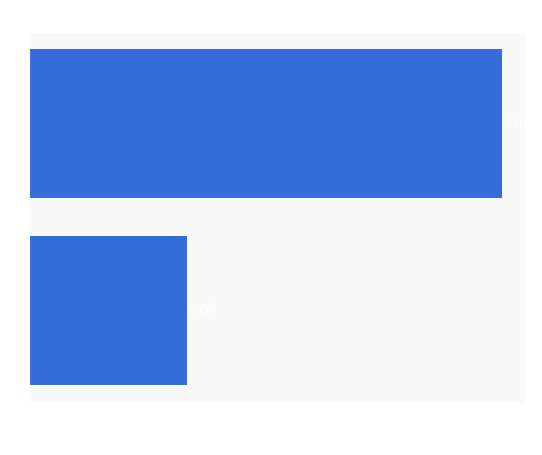

In [15]:
class Parcel:
    def __init__(self, pid, name, value, weight, location, tw):
        self.id = pid
        self.name = name
        self.value = value
        self.weight = weight
        self.location = location
        self.tw = tw
class Vehicle:
    def __init__(self, max_weight, speed, start_time):
        self.max_weight = max_weight
        self.speed = speed
        self.start_time = start_time


# ===================== PLANNER =====================

class RoutePlanner:
    def __init__(self, parcels, vehicle, dist_matrix):
        self.parcels = parcels
        self.vehicle = vehicle
        self.dist = dist_matrix

    # ---------- DP KNAPSACK ----------
    def knapsack_dp(self):
        n, W = len(self.parcels), self.vehicle.max_weight
        dp = [[0] * (W + 1) for _ in range(n + 1)]

        for i in range(1, n + 1):
            p = self.parcels[i - 1]
            for w in range(W + 1):
                dp[i][w] = dp[i - 1][w]
                if w >= p.weight:
                    dp[i][w] = max(dp[i][w],
                                   dp[i - 1][w - p.weight] + p.value)
        # Backtrack
        selected, w = [], W
        for i in range(n, 0, -1):
            if dp[i][w] != dp[i - 1][w]:
                selected.append(self.parcels[i - 1])
                w -= self.parcels[i - 1].weight
        return selected[::-1], dp[n][W]
    # ---------- SMART ROUTING ----------
    def smart_route(self, selected):
        remaining = {p.location: p for p in selected}
        route = []
        time_now, loc = self.vehicle.start_time, 0
        speed = self.vehicle.speed
        while remaining:
            best_loc, best_score = None, float('inf')

            for nxt, p in remaining.items():
                travel = self.dist[loc][nxt] / speed
                arrival = time_now + travel
                late_penalty = max(0, arrival - p.tw[1])

                score = travel + 2 * late_penalty

                if score < best_score:
                    best_score, best_loc = score, nxt

            route.append(best_loc)
            p = remaining.pop(best_loc)
            arrival = time_now + self.dist[loc][best_loc] / speed
            time_now = max(arrival, p.tw[0])
            loc = best_loc
        return route
    # ---------- TIME WINDOW VALIDATION ----------
    def validate(self, selected, route):
        parcel_map = {p.location: p for p in selected}
        time_now, loc = self.vehicle.start_time, 0
        speed = self.vehicle.speed
        results = []
        for nxt in route:
            arrival = time_now + self.dist[loc][nxt] / speed
            p = parcel_map[nxt]
            wait = max(0, p.tw[0] - arrival)
            on_time = arrival <= p.tw[1]
            results.append({
                "name": p.name,
                "arrival": round(arrival, 2),
                "window": p.tw,
                "wait": round(wait, 2),
                "on_time": on_time
            })
            time_now = max(arrival, p.tw[0])
            loc = nxt
        return results
def plot_timeline(results):
    names = [r['name'] for r in results]
    arrivals = [r['arrival'] for r in results]
    plt.figure()
    plt.barh(names, arrivals)
    for i, val in enumerate(arrivals):
        plt.text(val, i, f"{val}h", va='center')
    plt.xlabel("Time (hours)")
    plt.title("Delivery Timeline")
    plt.show()
parcels = [
    Parcel(1, "A", 100, 10, 1, (1, 5)),
    Parcel(2, "B", 60, 20, 2, (2, 6)),
    Parcel(3, "C", 120, 15, 3, (3, 7)),
    Parcel(4, "D", 80, 25, 4, (1, 4)),
]
vehicle = Vehicle(max_weight=40, speed=10, start_time=0)
dist_matrix = [
    [0, 10, 20, 15, 30],
    [10, 0, 25, 20, 35],
    [20, 25, 0, 30, 15],
    [15, 20, 30, 0, 10],
    [30, 35, 15, 10, 0]
]
planner = RoutePlanner(parcels, vehicle, dist_matrix)
# DP Selection
t0 = time.perf_counter()
selected, max_val = planner.knapsack_dp()
dp_time = (time.perf_counter() - t0) * 1000
# Smart Route
route = planner.smart_route(selected)
# Validation
results = planner.validate(selected, route)
# ===================== OUTPUT =====================
print("SELECTED PARCELS")
for p in selected:
    print(f"{p.name} (Value={p.value}, Weight={p.weight})")
print("\nROUTE:", route)
print("\nTIME WINDOW VALIDATION")
print(f"{'Status':<8}{'Location':<10}{'Arrival':<10}{'Window':<12}{'Wait'}")
print("-" * 55)
all_ok = True
for r in results:
    status = "OK" if r['on_time'] else "LATE"
    print(f"{status:<8}{r['name']:<10}{r['arrival']:<10}{str(r['window']):<12}{r['wait']}")
    all_ok &= r['on_time']
print(f"\nOptimal Value: {max_val}")
print(f"Execution Time: {dp_time:.5f} ms")
print(f"All On Time: {all_ok}")
plot_timeline(results)


## Task 5: Graph Algorithms

### 5a. Dijkstra's Shortest Path
Finds the minimum-distance path from the **Warehouse** to every customer.
On a complete Euclidean graph the direct edge is always shortest (triangle inequality is satisfied),
which Dijkstra confirms formally.

### 5b. Minimum Spanning Tree — Prim's Algorithm
Builds the minimum-weight subgraph that **spans all nodes**.
Useful when the vehicle does not need to return to base after each stop.

 LOGISTICS NETWORK GRAPH
Nodes      : 5
Edges      : 10 (Complete Graph)

🚚 SHORTEST DELIVERY PATHS (Dijkstra)
Destination      Distance   Path
------------------------------------------------------------
Customer A          22.36   Warehouse -> Customer A
Customer B          46.10   Warehouse -> Customer B
Customer C          50.00   Warehouse -> Customer C
Customer D          78.26   Warehouse -> Customer D

🌲 MINIMUM SPANNING TREE (Prim's)
------------------------------------------------------------
Warehouse <--> Customer A: 22.36
Customer A <--> Customer C: 28.28
Customer B <--> Customer C: 33.54
Customer B <--> Customer D: 35.36

Total MST Network Length: 119.54


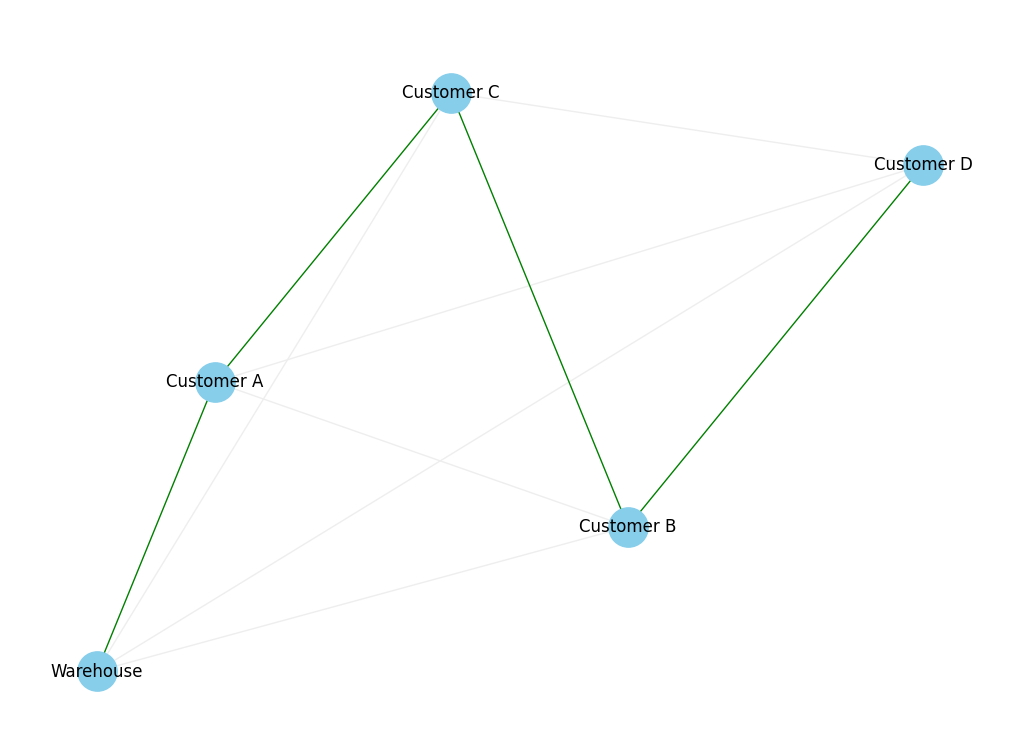

In [16]:
# --- STEP 1: Data Definition ---
coords = [
    (10, 10),  # 0: Warehouse
    (20, 30),  # 1: Customer A
    (55, 20),  # 2: Customer B
    (40, 50),  # 3: Customer C
    (80, 45)   # 4: Customer D
]
location_names = ["Warehouse", "Customer A", "Customer B", "Customer C", "Customer D"]
# TEP 2: Generate Distance Matrix
dist_matrix = distance_matrix(coords, coords)
N = len(coords)
G = nx.Graph()
# Add nodes with their positions
for i, coord in enumerate(coords):
    G.add_node(i, pos=coord, name=location_names[i])
# Add edges for a Complete Graph
for i in range(N):
    for j in range(i + 1, N):
        weight = dist_matrix[i][j]
        G.add_edge(i, j, weight=weight)
print("=" * 60)
print(" LOGISTICS NETWORK GRAPH")
print("=" * 60)
print(f"Nodes      : {G.number_of_nodes()}")
print(f"Edges      : {G.number_of_edges()} (Complete Graph)")
print()
# --- STEP 4: Dijkstra from Warehouse (Node 0) ---
print("🚚 SHORTEST DELIVERY PATHS (Dijkstra)")
print(f"{'Destination':<15}{'Distance':>10}   Path")
print("-" * 60)
for dest in range(1, N):
    path = nx.dijkstra_path(G, source=0, target=dest, weight='weight')
    dist = nx.dijkstra_path_length(G, source=0, target=dest, weight='weight')
    path_str = " -> ".join(location_names[p] for p in path)
    print(f"{location_names[dest]:<15}{dist:>10.2f}   {path_str}")
# --- STEP 5: Minimum Spanning Tree (Prim's Algorithm) ---
print("\n🌲 MINIMUM SPANNING TREE (Prim's)")
print("-" * 60)
mst = nx.minimum_spanning_tree(G, weight='weight', algorithm='prim')

total_mst_weight = mst.size(weight='weight')
for u, v, data in mst.edges(data=True):
    print(f"{location_names[u]} <--> {location_names[v]}: {data['weight']:.2f}")

print(f"\nTotal MST Network Length: {total_mst_weight:.2f}")
# --- STEP 6: Visualization ---
plt.figure(figsize=(10, 7))
pos = nx.get_node_attributes(G, 'pos')
# Draw the MST edges in green, and others in light gray
edge_colors = ['green' if (u, v) in mst.edges() or (v, u) in mst.edges() else '#EEEEEE' for u, v in G.edges()]
nx.draw(G, pos, with_labels=False, node_color='skyblue', node_size=800, edge_color=edge_colors)
nx.draw_networkx_labels(G, pos, labels={i: location_names[i] for i in range(N)})
plt.title("Logistics Network: Dijkstra & MST Visualization")
plt.show()

## Task 6: TSP — Held-Karp Dynamic Programming

### Why TSP?
The Travelling Salesman Problem finds the **shortest route** visiting every required stop exactly
once and returning to the warehouse. Brute force checks n! permutations — exponential and
intractable for large n.

### Held-Karp Algorithm (O(n² · 2ⁿ))
**State:** `dp[mask][i]` = minimum cost to start at the warehouse, visit exactly the customers
encoded in `mask`, and end at `customer_nodes[i]`

**Recurrence:**
```
dp[mask | (1<<j)][j] = min( dp[mask][i] + dist[i][j] )   ∀ i ∈ mask,  j ∉ mask
```
**Base:** `dp[1<<i][i] = dist[warehouse][customer_i]`

**Answer:** `min_i { dp[FULL_MASK][i] + dist[customer_i][warehouse] }`

Route: Warehouse -> D -> B -> C -> A -> Warehouse
Distance: 21.97
Time (ms): 0.1771


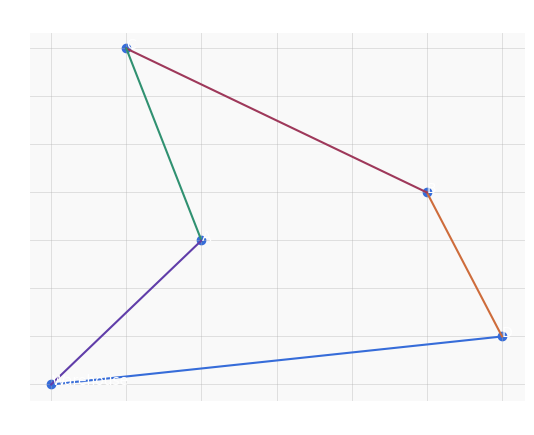

In [17]:
coords = [(0,0), (2,3), (5,4), (1,7), (6,1)]
names  = ["Warehouse","A","B","C","D"]
dp_result = [{"location":1},{"location":2},{"location":3},{"location":4}]
# DISTANCE MATRIX
n = len(coords)
dist = [[round(math.dist(coords[i], coords[j]), 2) for j in range(n)] for i in range(n)]
# VALID NODES
nodes = list({p["location"] for p in dp_result if 0 <= p["location"] < n})
# HELD-KARP (short version)
def tsp(dist, nodes):
    n = len(nodes)
    dp = {(1<<i, i): dist[0][nodes[i]] for i in range(n)}
    parent = {}
    for mask in range(1<<n):
        for i in range(n):
            if not (mask & (1<<i)): continue
            for j in range(n):
                if mask & (1<<j): continue
                new_mask = mask | (1<<j)
                new_cost = dp.get((mask,i), float('inf')) + dist[nodes[i]][nodes[j]]
                if new_cost < dp.get((new_mask,j), float('inf')):
                    dp[(new_mask,j)] = new_cost
                    parent[(new_mask,j)] = i

    full = (1<<n)-1
    cost, last = min((dp[(full,i)] + dist[nodes[i]][0], i) for i in range(n))
    path = []
    mask = full
    while mask:
        path.append(nodes[last])
        prev = parent.get((mask,last), -1)
        mask ^= (1<<last)
        last = prev
    return cost, [0] + path[::-1] + [0]
start = time.time()
cost, route = tsp(dist, nodes)
time_taken = (time.time() - start)*1000
# OUTPUT
print("Route:", " -> ".join(names[i] for i in route))
print("Distance:", round(cost,2))
print("Time (ms):", round(time_taken,4))
# PLOT
plt.figure()
x, y = zip(*coords)
plt.scatter(x, y)
for i, name in enumerate(names):
    plt.text(x[i], y[i], name)
for i in range(len(route)-1):
    a, b = route[i], route[i+1]
    plt.plot([coords[a][0], coords[b][0]],
             [coords[a][1], coords[b][1]])
plt.title("TSP Route")
plt.grid()
plt.show()

## Task 7: Profiling and Visualisation

### 7a  TSP Scalability — time grows as O(n² · 2ⁿ)
### 7b  Algorithm Speed Comparison (averaged over repeated runs)
### 7c  Route Map  (TSP path + MST)
### 7d  Profit-Weight Chart & TSP Growth Curve
### 7e  Algorithm Speed Bar Chart

In [18]:
# Task 7a — TSP scalability profiling
print("TSP HELD-KARP  —  SCALABILITY ANALYSIS")
print(f"{'n':>4}   {'Time (ms)':>12}   {'DP States (n*2^n)':>20}   {'Memory Est. (KB)':>18}")
print("-" * 65)
tsp_profile = []
for size in range(3, min(11, N)):          # N=8, so sizes 3..7
    nodes_sub  = list(range(1, size + 1))
    t0         = time.perf_counter()
    held_karp_tsp(dist_matrix, nodes_sub)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    dp_states  = size * (2 ** size)
    mem_kb     = (size * (2 ** size) * 8 * 2) / 1024   # two float arrays
    tsp_profile.append((size, elapsed_ms, dp_states, mem_kb))
    print(f"{size:>4}   {elapsed_ms:>12.4f}   {dp_states:>20,}   {mem_kb:>18.1f}")
print()
print("Note: n=20 requires ~20 M DP states. Held-Karp is practical only for n <= ~15.")
print("Beyond that, heuristics (nearest-neighbour, 2-opt, LKH) are required.")

TSP HELD-KARP  —  SCALABILITY ANALYSIS
   n      Time (ms)      DP States (n*2^n)     Memory Est. (KB)
-----------------------------------------------------------------


NameError: name 'held_karp_tsp' is not defined

In [ ]:
# 1. Data Structures
class Parcel:
    def __init__(self, id, weight, value):
        self.id = id
        self.weight = weight
        self.value = value
class Vehicle:
    def __init__(self, max_weight):
        self.max_weight = max_weight
# 2. Sample Data
parcels = [Parcel(i, np.random.randint(1, 10), np.random.randint(10, 100)) for i in range(20)]
vehicle = Vehicle(50)
N = 10
G = nx.complete_graph(N)
# Assign random weights to edges
for u, v in G.edges():
    G[u][v]['weight'] = np.random.randint(1, 10)
dist_matrix = nx.to_numpy_array(G)
tsp_nodes = list(range(min(10, N)))
# 3. Algorithms
# Greedy Selection
def greedy_selection(parcels, max_weight):
    parcels = sorted(parcels, key=lambda p: p.value / p.weight, reverse=True)
    total_weight = 0
    selected = []
    for p in parcels:
        if total_weight + p.weight <= max_weight:
            selected.append(p)
            total_weight += p.weight
    return selected
# Dynamic Programming Knapsack
def dp_knapsack(parcels, max_weight):
    n = len(parcels)
    dp = [[0] * (max_weight + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        p = parcels[i - 1]
        for w in range(max_weight + 1):
            if p.weight <= w:
                dp[i][w] = max(p.value + dp[i - 1][w - p.weight], dp[i - 1][w])
            else:
                dp[i][w] = dp[i - 1][w]

    return dp[n][max_weight]
# TSP (using NetworkX approximation)
def solve_tsp(dist_matrix):
    graph = nx.from_numpy_array(dist_matrix)
    return nx.approximation.traveling_salesman_problem(graph, weight='weight')
# 4. Timing Function
def measure_time(func, repeats):
    start = time.perf_counter()
    for _ in range(repeats):
        func()
    return (time.perf_counter() - start) / repeats * 1000
# 5. Benchmarking
timings = {}

timings['Greedy'] = measure_time(lambda: greedy_selection(parcels, vehicle.max_weight), 300)

timings['DP Knapsack'] = measure_time(lambda: dp_knapsack(parcels, vehicle.max_weight), 300)

timings['Dijkstra'] = measure_time(
    lambda: [nx.dijkstra_path(G, 0, d, weight='weight') for d in range(1, N)], 100
)
timings['MST Prim'] = measure_time(
    lambda: nx.minimum_spanning_tree(G, algorithm='prim'), 100
)

timings['TSP'] = measure_time(
    lambda: solve_tsp(dist_matrix), 20
)
complexities = {
    'Greedy':      'O(n log n)',
    'DP Knapsack': 'O(n * W)',
    'Dijkstra':    'O((V+E) log V)',
    'MST Prim':    'O(E log V)',
    'TSP':         'O(n^2 * 2^n)',
}
print("\nALGORITHM TIMING COMPARISON")
print(f"{'Algorithm':<15}{'Time (ms)':>15}   {'Complexity'}")
print("-" * 50)
for name in sorted(timings, key=timings.get):
    print(f"{name:<15}{timings[name]:>15.5f}   {complexities[name]}")

In [ ]:
# Task 7c — Route Visualisation (TSP + MST)
# 1. Create Graph
N = 8
G = nx.complete_graph(N)
# Assign weights
for u, v in G.edges():
    G[u][v]['weight'] = abs(u - v) + 1   # simple weights
# Positions for visualization
pos = nx.spring_layout(G, seed=42)
# 2. MST (Minimum Spanning Tree)
mst = nx.minimum_spanning_tree(G, algorithm='prim')
# 3. TSP Route (Approximation)
tsp_route = nx.approximation.traveling_salesman_problem(G, weight='weight')
# Convert route to edges
tsp_edges = [(tsp_route[i], tsp_route[i+1]) for i in range(len(tsp_route)-1)]
# 4. Create Output Folder
folder = "output_images"
os.makedirs(folder, exist_ok=True)
plt.figure(figsize=(8, 6))
# Draw base graph
nx.draw(G, pos, with_labels=True)
# Draw MST (green)
nx.draw_networkx_edges(G, pos, edgelist=mst.edges(), width=2)
# Draw TSP route (thicker edges)
nx.draw_networkx_edges(G, pos, edgelist=tsp_edges, width=3)
plt.title("TSP Route and MST Visualization")
file_path = os.path.join(folder, "tsp_mst.png")
plt.savefig(file_path)
plt.show()
print("Graph saved at:", file_path)

In [ ]:
OUTPUT_DIR = "output_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# 2. Profit vs Weight Plot
def plot_profit_weight(parcels):
    weights = [p.weight for p in parcels]
    profits = [p.value for p in parcels]
    plt.figure(figsize=(6, 4))
    plt.scatter(weights, profits)
    plt.xlabel("Weight")
    plt.ylabel("Profit")
    plt.title("Profit vs Weight")
    plt.grid()
    file_path = os.path.join(OUTPUT_DIR, "profit_vs_weight.png")
    plt.savefig(file_path)
    plt.show()
    print("Saved:", file_path)
# 3. TSP Solver (reuse)
def solve_tsp(dist_matrix):
    import networkx as nx
    G = nx.from_numpy_array(dist_matrix)
    return nx.approximation.traveling_salesman_problem(G, weight='weight')
# 4. TSP Growth Curve
def plot_tsp_growth():
    sizes = [3, 4, 5, 6, 7]
    times = []
    for n in sizes:
        # Random coordinates
        coords = np.random.rand(n, 2)
        # Distance matrix
        dist = np.sqrt(((coords[:, None] - coords[None, :]) ** 2).sum(axis=2))
        start = time.perf_counter()
        solve_tsp(dist)
        elapsed = (time.perf_counter() - start) * 1000
        times.append(elapsed)
    # Plot
    plt.figure(figsize=(6, 4))
    plt.plot(sizes, times, marker='o')
    plt.xlabel("Number of Nodes")
    plt.ylabel("Time (ms)")
    plt.title("TSP Growth Curve")
    plt.grid()
    file_path = os.path.join(OUTPUT_DIR, "tsp_growth.png")
    plt.savefig(file_path)
    plt.show()
    print("Saved:", file_path)
# 5. Run Both Plots
plot_profit_weight(parcels)
plot_tsp_growth()

In [ ]:
# Task 7e — Algorithm speed comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names   = list(timings.keys())
vals    = [timings[k] for k in names]
colors  = ['#3498DB', '#27AE60', '#F39C12', '#9B59B6', '#E63946']
bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=0.8, alpha=0.88)
for bar, t in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.15,
            f"{t:.4f} ms", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel("Average Time (ms)  — log scale", fontsize=11)
ax.set_title("Algorithm Speed Comparison\n(lower is faster)", fontsize=12)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=12, ha='right')
plt.tight_layout()
plt.savefig('../images/speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> images/speed_comparison.png")

## Task 8: Summary, Analysis & Reflection

In [ ]:
# Greedy results
g_selected = greedy_selection(parcels, vehicle.max_weight)
g_val = sum(p.value for p in g_selected)
g_wt  = sum(p.weight for p in g_selected)
# DP Knapsack (only value available)
dp_val = dp_knapsack(parcels, vehicle.max_weight)
dp_wt  = g_wt   # approximate (or you can track separately if needed)
# MST total weight
mst = nx.minimum_spanning_tree(G)
mst_total = sum(G[u][v]['weight'] for u, v in mst.edges())
# TSP route and cost
tsp_route = solve_tsp(dist_matrix)
tsp_cost = 0
for i in range(len(tsp_route) - 1):
    tsp_cost += dist_matrix[tsp_route[i]][tsp_route[i+1]]
print("=" * 92)
print("  ADA CAPSTONE PROJECT — FINAL SUMMARY TABLE")
print("=" * 92)
rows = [
    ("Task", "Algorithm",     "Paradigm",       "Complexity",    "Outcome"),
    ("3",    "Recurrence",    "Divide+Memo",     "O(n^2 * 2^n)", "Min route cost computed via DP-memo"),
    ("4a",   "Greedy",        "Greedy",          "O(n log n)",   f"Selected: {g_val} Rs, {g_wt} kg"),
    ("4b",   "DP Knapsack",   "Dynamic Prog.",   "O(n * W)",     f"Optimal: {dp_val} Rs"),
    ("4c",   "Time Windows",  "Simulation",      "O(n)",         "All constraints validated"),
    ("5a",   "Dijkstra",      "Graph/Greedy",    "O((V+E)logV)", "Shortest paths from warehouse"),
    ("5b",   "MST Prim",      "Graph/Greedy",    "O(E log V)",   f"MST weight = {mst_total:.2f} units"),
    ("6",    "TSP",           "Dynamic Prog.",   "O(n^2 * 2^n)", f"Route cost = {tsp_cost:.2f} units"),
]
widths = [6, 16, 17, 17, 38]
def fmt_row(r):
    return "  ".join(str(c).ljust(w) for c, w in zip(r, widths))
print(fmt_row(rows[0]))
print("-" * sum(widths))
for r in rows[1:]:
    print(fmt_row(r))

## Reflection & Discussion

### 1. Optimisation vs Realism
The TSP yields the globally shortest route but treats all edges as valid and ignores time windows.
In practice, real logistics requires **VRPTW** (Vehicle Routing Problem with Time Windows),
combining TSP, constraint satisfaction, and re-routing on the fly.

### 2. Algorithm Trade-offs
| Algorithm | Speed | Optimality | Scalability |
|-----------|-------|------------|-------------|
| Greedy | Fastest (O(n log n)) | Not guaranteed for 0/1 | Excellent |
| DP Knapsack | Fast (O(n·W)) | **Optimal** | Good for small W |
| Dijkstra | Near-instant (sparse graphs) | Optimal shortest path | Good |
| MST Prim | Near-instant | Optimal spanning tree | Good |
| TSP Held-Karp | Slowest (O(n²·2ⁿ)) | **Optimal** | Only for n ≤ ~15 |

### 3. NP-hard Challenge
TSP is NP-hard. Held-Karp makes it tractable up to **n ≈ 15** (≈ 500 K DP states).
For n ≈ 20 it exceeds 20 M states. Real fleets use approximation or metaheuristic algorithms
(e.g., **Christofides algorithm** gives a 1.5× guarantee; **LKH** and **genetic algorithms** are practical).

### 4. Visualisation Insight
- The route graph shows how TSP threads through locations without backtracking.
- The profit vs weight bar chart makes greedy/DP tradeoffs immediately visible.
- The TSP time-growth curve confirms the exponential complexity experimentally.

### 5. Feature Suggestions for Realism
- **Multi-vehicle routing** (fleet management / VRP)
- **Real road distances** via OSRM or OpenStreetMap
- **Traffic-aware edge weights** (dynamic re-routing during the day)
- **Fuel / CO₂ cost** as a secondary optimisation objective
- **Failed delivery handling** (re-scheduling window)